# Customer Retention & RFM Analysis

**Project Objective:**  
Analyze online retail customers to understand retention patterns and identify high-value segments.

**Business Questions:**  
1. How long do customers stay active after their first purchase?  
2. Which customers generate the most revenue?  
3. Where should marketing focus for retention and engagement?

**Tools Used:**  
- Python (pandas, seaborn, matplotlib)

**Key Insights:**  
- Retention drops sharply after the first month.
- Loyal Customers contribute the largest share of revenue (~11.6M).
- Most customers are one-time buyers, highlighting opportunities to improve repeat purchase behavior.


# Cohort Analysis
A cohort is a group of customers that started at the same time (purchased for the first time in this case)

In [7]:
import pandas as pd

In [8]:
df = pd.read_csv('/Users/aaliyahgritly/Downloads/Bebo study items/(P3) E-commerce project/cleaned_online_retail_II.csv')

df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,customer_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Repeat
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Repeat
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Repeat
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Repeat
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Repeat


In [20]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors = 'coerce')

Create `first_purchase_date` column

In [ ]:
# find the first purchase date for each customer by grouping by customer_id and taking the minimum invoicedate
df['first_purchase_date'] = (
    df.groupby('customer_id')['invoicedate']
      .transform('min')
)


Creat `invoice_month` and `cohort_month` columns

In [ ]:
df['invoice_month'] = df['invoicedate'].dt.to_period('M') # create invoice month by converting InvoiceDate to period month
df['cohort_month'] = df['first_purchase_date'].dt.to_period('M') # cohort month is the month of the first purchase


In [28]:
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue,customer_type,first_purchase_date,invoice_month,cohort_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,Repeat,2009-12-01 07:45:00,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Repeat,2009-12-01 07:45:00,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,Repeat,2009-12-01 07:45:00,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,Repeat,2009-12-01 07:45:00,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,Repeat,2009-12-01 07:45:00,2009-12,2009-12


Create `cohort_index` column

In [ ]:
# cohort index tells us the amount of time (in months) since the customer's first purchase
df['cohort_index'] = (
    (df['invoice_month'].dt.year - df['cohort_month'].dt.year) * 12 + (df['invoice_month'].dt.month - df['cohort_month'].dt.month) + 1)

Cohort data table (dataframe)

In [ ]:
# create a cohort data DataFrame counting unique customers per cohort month and cohort index
cohort_data = (df.groupby(['cohort_month', 'cohort_index'])
               ['customer_id'].nunique().reset_index())

cohort_data.head()

,cohort_month,cohort_index,customer_id
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363


Creat cohort data pivot table

In [ ]:
# create a pivot table with cohort_month as index, cohort_index as columns, and customer_id as values
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)


In [38]:
cohort_pivot.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN


In [ ]:
# calculate retention by dividing each value in the pivot table by the size of the cohort (the number of unique customers in cohort_index 1)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0)


In [ ]:
# NaNs represent months where there were no customers from that cohort making purchases
retention.round(3)

cohort_index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.353,0.334,0.425,0.380,0.359,0.377,0.342,0.336,0.362,...,0.303,0.263,0.303,0.283,0.260,0.255,0.315,0.305,0.407,0.197
2010-01,1.0,0.206,0.311,0.305,0.264,0.300,0.258,0.230,0.279,0.319,...,0.151,0.235,0.198,0.185,0.196,0.243,0.193,0.245,0.057,NaN
2010-02,1.0,0.238,0.225,0.291,0.246,0.201,0.193,0.286,0.254,0.275,...,0.201,0.160,0.163,0.144,0.230,0.230,0.163,0.059,NaN,NaN
2010-03,1.0,0.190,0.230,0.242,0.233,0.203,0.246,0.302,0.275,0.108,...,0.169,0.174,0.156,0.176,0.201,0.212,0.079,NaN,NaN,NaN
2010-04,1.0,0.194,0.194,0.163,0.184,0.224,0.276,0.262,0.105,0.109,...,0.156,0.139,0.150,0.180,0.224,0.058,NaN,NaN,NaN,NaN
2010-05,1.0,0.157,0.169,0.173,0.177,0.256,0.213,0.126,0.059,0.083,...,0.126,0.138,0.165,0.154,0.047,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.174,0.189,0.204,0.230,0.285,0.126,0.089,0.081,0.119,...,0.122,0.133,0.204,0.052,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.156,0.183,0.296,0.290,0.140,0.113,0.145,0.145,0.113,...,0.172,0.237,0.081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.204,0.296,0.321,0.173,0.117,0.099,0.123,0.136,0.130,...,0.198,0.068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Create a heatmap to visualize the cohort 

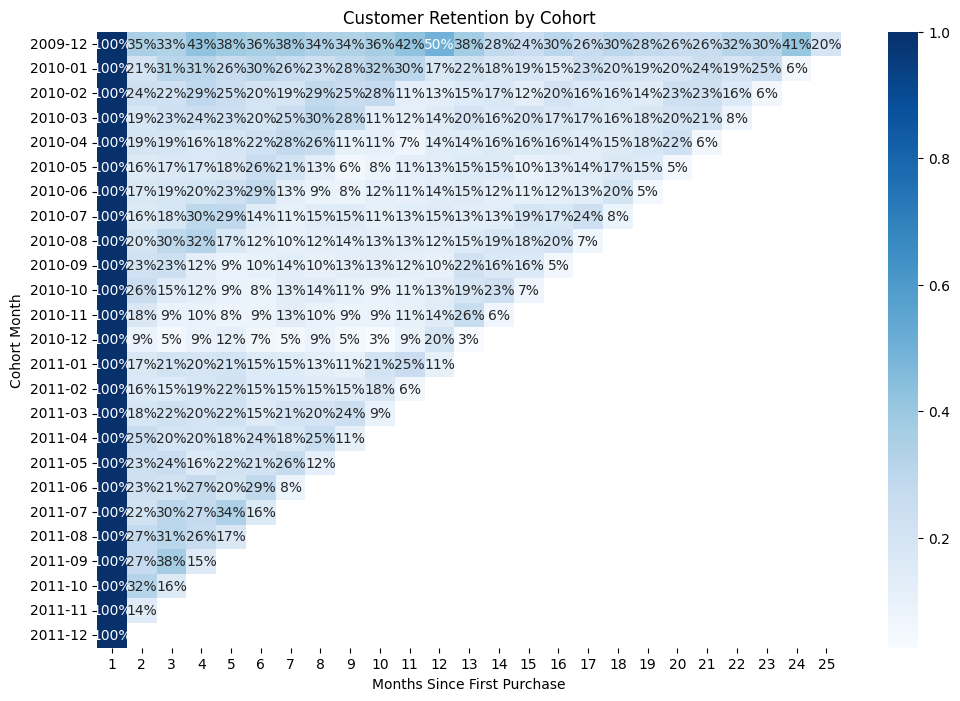

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()


### Cohort Analysis Insights
- Retention drops sharply after the first month across all cohorts, highlighting early churn as a major issue.
- Newer cohorts show slightly better retention than older cohorts, suggesting some improvement in customer engagement over time.
- Most customers do not return beyond 3–4 months, indicating opportunities for retention campaigns targeting the first few months.
- Heatmap visualization makes patterns of churn and retention immediately visible.

# RFM Segmentation
Find who your best customers are

In [41]:
# define snapshot date as one day after the last invoice date in the dataset
snapshot_date = df['invoicedate'].max() + pd.Timedelta(days=1)

In [ ]:
# calculate RFM metrics: Recency (days since last purchase), Frequency (number of purchases), Monetary (total revenue)
rfm = (df.groupby('customer_id').agg({
          'invoicedate': lambda x: (snapshot_date - x.max()).days,
          'invoice': 'nunique',
          'revenue': 'sum'
      })
      .reset_index()
)
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']


In [44]:
rfm.head()

,customer_id,recency,frequency,monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


Create RFM scores [1 -4]

In [ ]:
# assign R, F, M scores based on quartiles, with 1 being the lowest and 4 being the highest
rfm['R_score'] = pd.qcut(rfm['recency'], q=4, duplicates='drop', labels=False) + 1 # lower recency = better score

rfm['F_score'] = pd.qcut(rfm['frequency'], q=4, duplicates='drop', labels=False) + 1 # higher frequency = better score

rfm['M_score'] = pd.qcut(rfm['monetary'], q=4, duplicates='drop', labels=False) + 1 # higher monetary = better score

In [50]:
rfm['R_score'] = 5 - rfm['R_score'] # invert R_score so that higher recency gets higher score

In [53]:
rfm[['R_score', 'F_score', 'M_score']].describe()

,R_score,F_score,M_score
count,5878.000000,5878.000000,5878.000000
mean,2.511058,1.671317,2.500000
std,1.122631,0.814095,1.118281
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.250000
50%,3.000000,1.000000,2.500000
75%,4.000000,2.000000,3.750000
max,4.000000,3.000000,4.000000


Combined RFM score

In [57]:
rfm['RFM_score'] = (rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)) # combine R, F, M scores into a single RFM score string

rfm['RFM_score'].head()

0    234
1    434
2    323
3    424
4    211
Name: RFM_score, dtype: object

In [58]:
def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Legends'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_score'] == 1:
        return 'At Risk'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(rfm_segment, axis=1) # segment customers based on R and F scores

In [59]:
rfm['segment'].value_counts()

segment
Potential Loyalists    1843
Others                 1466
At Risk                1459
Loyal Customers        1110
Name: count, dtype: int64

In [ ]:
rfm.groupby('segment')['monetary'].sum().sort_values(ascending = False)

segment
Loyal Customers        1.162973e+07
Potential Loyalists    2.463252e+06
Others                 2.240542e+06
At Risk                1.041280e+06
Name: monetary, dtype: float64

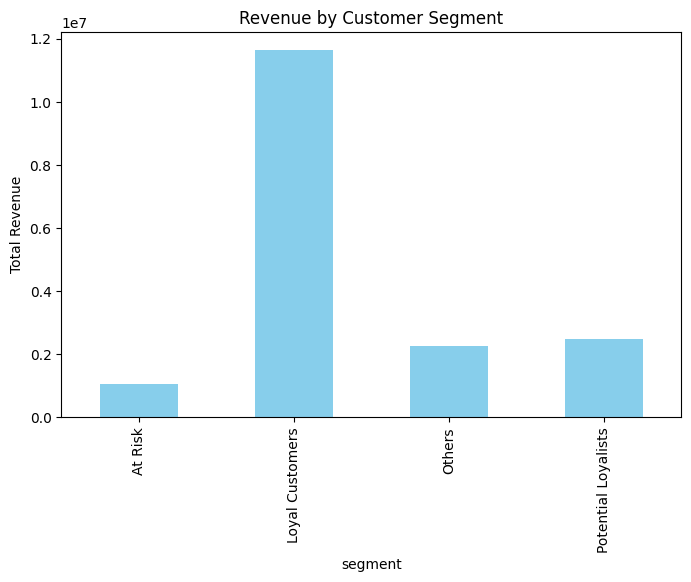

In [71]:
import matplotlib.pyplot as plt

rfm.groupby('segment')['monetary'].sum().plot(kind='bar', figsize=(8,5), color='skyblue')
plt.title("Revenue by Customer Segment")
plt.ylabel("Total Revenue")
plt.show()


### RFM Analysis Insights
- Loyal Customers, while not the largest group, contribute the majority of revenue (~11.6M), highlighting their strategic importance.
- Potential Loyalists and Others represent moderate revenue but have the potential to be converted to higher-value segments with targeted campaigns.
- At Risk customers contribute the least revenue (~1M) and may require re-engagement strategies to prevent churn.
- No Legends exist in this dataset, showing a lack of high-frequency, high-revenue customers — an opportunity for customer loyalty programs.


Total Revenue by customer type bargraph

/var/folders/sk/lq_95tyx0mvg_8rph7dgqtwm0000gn/T/ipykernel_25419/721185495.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_type.index, y=revenue_by_type.values, palette="viridis")


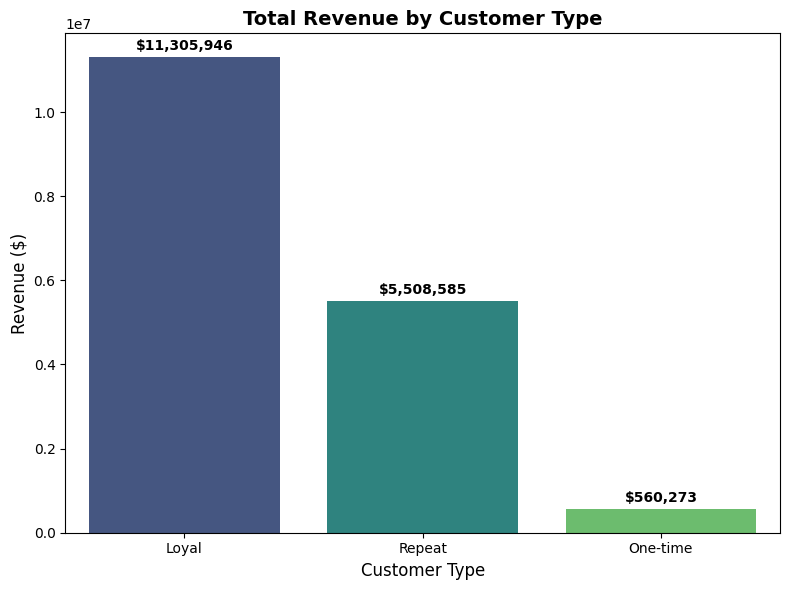

Revenue by Customer Type:
customer_type
Loyal       1.130595e+07
Repeat      5.508585e+06
One-time    5.602726e+05
Name: revenue, dtype: float64


In [73]:
# Calculate revenue by customer type
revenue_by_type = df.groupby("customer_type")["revenue"].sum().sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=revenue_by_type.index, y=revenue_by_type.values, palette="viridis")
plt.title("Total Revenue by Customer Type", fontsize=14, fontweight="bold")
plt.xlabel("Customer Type", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(revenue_by_type.values):
    plt.text(i, v + 100000, f"${v:,.0f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

# Display summary
print("Revenue by Customer Type:")
print(revenue_by_type)